## Comprobar HW y SW instalado








In [ ]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   2
  On-line CPU(s) list:    0,1
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   1
    Socket(s):            1
    Stepping:             3
    BogoMIPS:             4000.39
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 cl
                          flush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc re
                          p_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3
                           fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand
                           hypervisor lahf_lm abm 3dnowprefetch i

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Tue_Aug_15_22:02:13_PDT_2023
Cuda compilation tools, release 12.2, V12.2.140
Build cuda_12.2.r12.2/compiler.33191640_0


In [ ]:
!nvidia-smi

Thu Oct 24 18:23:46 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

## Compilar ejecutar un program (GoogleColab con GPUs)



In [ ]:
! mkdir cuda

In [ ]:
%%writefile cuda/holamundo.cu

#include <stdio.h>
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void mykernel(void) {

}

int main(void) {
		mykernel<<<1,1>>>();
		printf("Hello world\n");
		return 0;
}

Writing cuda/holamundo.cu


In [ ]:
!ls


cuda  sample_data


In [ ]:
!nvcc cuda/holamundo.cu -o cuda/holamundo
!ls -la cuda

total 960
drwxr-xr-x 2 root root   4096 Oct 24 18:23 .
drwxr-xr-x 1 root root   4096 Oct 24 18:23 ..
-rwxr-xr-x 1 root root 967080 Oct 24 18:23 holamundo
-rw-r--r-- 1 root root    183 Oct 24 18:23 holamundo.cu


In [ ]:
!./cuda/holamundo

Hello world


In [ ]:
%%writefile cuda/suma1d.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdio.h>

__global__ void add(int *a, int *b, int *c) {
    *c = *a + *b;
}

int main(void) {
    int a, b, c;				    // host copies of a, b, c
	  int *d_a, *d_b, *d_c;		// device copies of a, b, c
	  int size = sizeof(int);

	  // Allocate space for device copies of a, b, c
	  cudaMalloc((void **)&d_a, size);
	  cudaMalloc((void **)&d_b, size);
	  cudaMalloc((void **)&d_c, size);

	  // Setup input values
	  a = 2;
	  b = 7;

	  // Copy inputs to device
	  cudaMemcpy(d_a, &a, size, cudaMemcpyHostToDevice);
	  cudaMemcpy(d_b, &b, size, cudaMemcpyHostToDevice);

	  // Launch add() kernel on GPU
	  add<<<1,1>>>(d_a, d_b, d_c);

	  // Copy result back to host
	  cudaMemcpy(&c, d_c, size, cudaMemcpyDeviceToHost);

	  // Show result
	  printf("%d + %d = %d", a, b, c);

	  // Cleanup
	  cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
	  return 0;
}

Writing cuda/suma1d.cu


In [ ]:
!nvcc cuda/suma1d.cu -o cuda/suma1d
!ls -la cuda

total 1912
drwxr-xr-x 2 root root   4096 Oct 24 18:23 .
drwxr-xr-x 1 root root   4096 Oct 24 18:23 ..
-rwxr-xr-x 1 root root 967080 Oct 24 18:23 holamundo
-rw-r--r-- 1 root root    183 Oct 24 18:23 holamundo.cu
-rwxr-xr-x 1 root root 967072 Oct 24 18:23 suma1d
-rw-r--r-- 1 root root    906 Oct 24 18:23 suma1d.cu


In [ ]:
!./cuda/suma1d

2 + 7 = 9

Comprobar perfil de ejecución

In [ ]:
!nvprof cuda/suma1d

==1130== NVPROF is profiling process 1130, command: cuda/suma1d
==1130== Profiling application: cuda/suma1d
2 + 7 = 9==1130== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   46.49%  3.3920us         1  3.3920us  3.3920us  3.3920us  add(int*, int*, int*)
                   28.51%  2.0800us         1  2.0800us  2.0800us  2.0800us  [CUDA memcpy DtoH]
                   25.00%  1.8240us         2     912ns     672ns  1.1520us  [CUDA memcpy HtoD]
      API calls:   99.74%  237.60ms         3  79.200ms  5.2660us  237.59ms  cudaMalloc
                    0.09%  209.30us         1  209.30us  209.30us  209.30us  cudaLaunchKernel
                    0.08%  194.66us       114  1.7070us     194ns  64.956us  cuDeviceGetAttribute
                    0.05%  120.10us         3  40.034us  4.3930us  107.38us  cudaFree
                    0.02%  52.954us         3  17.651us  6.7640us  23.566us  cudaMemcpy
                    0.01%  14

### Compilar y ejecutar un programa (code in multiple source files)

In [ ]:
%%writefile cuda/kernel.cu
#include <cuda.h>

__global__ void add(int *a, int *b, int *c) {
    *c = *a + *b;
}

Writing cuda/kernel.cu


In [ ]:
%%writefile cuda/main.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdio.h>

__global__ void add(int *a, int *b, int *c);

int main(void) {
	int a, b, c;				    // host copies of a, b, c
	int *d_a, *d_b, *d_c;		// device copies of a, b, c
	int size = sizeof(int);

	// Allocate space for device copies of a, b, c
	cudaMalloc((void **)&d_a, size);
	cudaMalloc((void **)&d_b, size);
	cudaMalloc((void **)&d_c, size);

	// Setup input values
	a = 2;
	b = 7;

	// Copy inputs to device
	cudaMemcpy(d_a, &a, size, cudaMemcpyHostToDevice);
	cudaMemcpy(d_b, &b, size, cudaMemcpyHostToDevice);

	// Launch add() kernel on GPU
	add<<<1,1>>>(d_a, d_b, d_c);

	// Copy result back to host
	cudaMemcpy(&c, d_c, size, cudaMemcpyDeviceToHost);

	// Show result
	printf("%d + %d = %d", a, b, c);

	// Cleanup
	cudaFree(d_a); cudaFree(d_b); cudaFree(d_c);
	return 0;
}

Writing cuda/main.cu


In [ ]:
!nvcc cuda/kernel.cu cuda/main.cu -o cuda/program
!ls -la cuda

total 2868
drwxr-xr-x 2 root root   4096 Oct 24 18:24 .
drwxr-xr-x 1 root root   4096 Oct 24 18:23 ..
-rwxr-xr-x 1 root root 967080 Oct 24 18:23 holamundo
-rw-r--r-- 1 root root    183 Oct 24 18:23 holamundo.cu
-rw-r--r-- 1 root root     85 Oct 24 18:23 kernel.cu
-rw-r--r-- 1 root root    840 Oct 24 18:23 main.cu
-rwxr-xr-x 1 root root 967496 Oct 24 18:24 program
-rwxr-xr-x 1 root root 967072 Oct 24 18:23 suma1d
-rw-r--r-- 1 root root    906 Oct 24 18:23 suma1d.cu


In [ ]:
!./cuda/program

2 + 7 = 9

## Mount your Google Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
#drive.flush_and_unmount()
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
! ls -la gdrive/MyDrive/Colab\ Notebooks

total 1
-rw------- 1 root root 306 Oct  2 12:05 Untitled


In [ ]:
# Copy source code to your folder
!cp -r /content/gdrive/MyDrive/CAP/P2/images/* cuda/
# Create soft links
!ln -s /content/gdrive/MyDrive/CAP/P2/images cuda

!cp  /content/gdrive/MyDrive/CAP/P2/stb_image.h cuda/
!cp /content/gdrive/MyDrive/CAP/P2/stb_image_write.h cuda/

# Create soft links
!ln -s /content/gdrive/MyDrive/CAP/P2/stdb_image.h cuda
!ln -s /content/gdrive/MyDrive/CAP/P2/stdb_image_write.h cuda

# List folder
!ls -la cuda/

cp: cannot stat '/content/gdrive/MyDrive/CAP/P2/images/*': No such file or directory
cp: cannot stat '/content/gdrive/MyDrive/CAP/P2/stb_image.h': No such file or directory
cp: cannot stat '/content/gdrive/MyDrive/CAP/P2/stb_image_write.h': No such file or directory
total 2868
drwxr-xr-x 2 root root   4096 Oct 24 18:24 .
drwxr-xr-x 1 root root   4096 Oct 24 18:24 ..
-rwxr-xr-x 1 root root 967080 Oct 24 18:23 holamundo
-rw-r--r-- 1 root root    183 Oct 24 18:23 holamundo.cu
lrwxrwxrwx 1 root root     37 Oct 24 18:24 images -> /content/gdrive/MyDrive/CAP/P2/images
-rw-r--r-- 1 root root     85 Oct 24 18:23 kernel.cu
-rw-r--r-- 1 root root    840 Oct 24 18:23 main.cu
-rwxr-xr-x 1 root root 967496 Oct 24 18:24 program
lrwxrwxrwx 1 root root     43 Oct 24 18:24 stdb_image.h -> /content/gdrive/MyDrive/CAP/P2/stdb_image.h
lrwxrwxrwx 1 root root     49 Oct 24 18:24 stdb_image_write.h -> /content/gdrive/MyDrive/CAP/P2/stdb_image_write.h
-rwxr-xr-x 1 root root 967072 Oct 24 18:23 suma1d
-rw-r--r

In [ ]:
!pwd

/content


## Compilar ejemplos de CUDA

In [ ]:
cd /content/cuda

/content/cuda


In [ ]:
!git clone https://github.com/NVIDIA/cuda-samples.git

Cloning into 'cuda-samples'...
remote: Enumerating objects: 19507, done.
remote: Counting objects: 100% (4922/4922), done.
remote: Compressing objects: 100% (658/658), done.
remote: Total 19507 (delta 4565), reused 4336 (delta 4264), pack-reused 14585 (from 1)
Receiving objects: 100% (19507/19507), 133.38 MiB | 19.87 MiB/s, done.
Resolving deltas: 100% (17225/17225), done.
Updating files: 100% (4026/4026), done.


In [ ]:
ls /content/cuda/cuda-samples/Samples/*

/content/cuda/cuda-samples/Samples/0_Introduction:
asyncAPI/                simpleAtomicIntrinsics_nvrtc/  simpleSeparateCompilation/
c++11_cuda/              simpleAttributes/              simpleStreams/
clock/                   simpleAWBarrier/               simpleSurfaceWrite/
clock_nvrtc/             simpleCallback/                simpleTemplates/
concurrentKernels/       simpleCooperativeGroups/       simpleTemplates_nvrtc/
cppIntegration/          simpleCubemapTexture/          simpleTexture/
cppOverload/             simpleCUDA2GL/                 simpleTexture3D/
cudaOpenMP/              simpleDrvRuntime/              simpleTextureDrv/
fp16ScalarProduct/       simpleHyperQ/                  simpleVoteIntrinsics/
matrixMul/               simpleIPC/                     simpleVoteIntrinsics_nvrtc/
matrixMulDrv/            simpleLayeredTexture/          simpleZeroCopy/
matrixMulDynlinkJIT/     simpleMPI/                     systemWideAtomics/
matrixMul_nvrtc/         simpleMultiCopy

In [ ]:
cd /content/cuda/cuda-samples/Samples/1_Utilities/deviceQuery

/content/cuda/cuda-samples/Samples/1_Utilities/deviceQuery


In [ ]:
!ls -la

total 88
drwxr-xr-x 3 root root  4096 Oct 24 18:24 .
drwxr-xr-x 6 root root  4096 Oct 24 18:24 ..
-rw-r--r-- 1 root root 13921 Oct 24 18:24 deviceQuery.cpp
-rw-r--r-- 1 root root   851 Oct 24 18:24 deviceQuery_vs2017.sln
-rw-r--r-- 1 root root  5199 Oct 24 18:24 deviceQuery_vs2017.vcxproj
-rw-r--r-- 1 root root   851 Oct 24 18:24 deviceQuery_vs2019.sln
-rw-r--r-- 1 root root  4784 Oct 24 18:24 deviceQuery_vs2019.vcxproj
-rw-r--r-- 1 root root   851 Oct 24 18:24 deviceQuery_vs2022.sln
-rw-r--r-- 1 root root  4784 Oct 24 18:24 deviceQuery_vs2022.vcxproj
-rw-r--r-- 1 root root 12973 Oct 24 18:24 Makefile
-rw-r--r-- 1 root root  2154 Oct 24 18:24 NsightEclipse.xml
-rw-r--r-- 1 root root  3639 Oct 24 18:24 README.md
drwxr-xr-x 2 root root  4096 Oct 24 18:24 .vscode


In [ ]:
!make

/usr/local/cuda/bin/nvcc -ccbin g++ -I../../../Common -m64 --threads 0 --std=c++11 -gencode arch=compute_50,code=sm_50 -gencode arch=compute_52,code=sm_52 -gencode arch=compute_60,code=sm_60 -gencode arch=compute_61,code=sm_61 -gencode arch=compute_70,code=sm_70 -gencode arch=compute_75,code=sm_75 -gencode arch=compute_80,code=sm_80 -gencode arch=compute_86,code=sm_86 -gencode arch=compute_89,code=sm_89 -gencode arch=compute_90,code=sm_90 -gencode arch=compute_90,code=compute_90 -o deviceQuery.o -c deviceQuery.cpp
/usr/local/cuda/bin/nvcc -ccbin g++ -m64 -gencode arch=compute_50,code=sm_50 -gencode arch=compute_52,code=sm_52 -gencode arch=compute_60,code=sm_60 -gencode arch=compute_61,code=sm_61 -gencode arch=compute_70,code=sm_70 -gencode arch=compute_75,code=sm_75 -gencode arch=compute_80,code=sm_80 -gencode arch=compute_86,code=sm_86 -gencode arch=compute_89,code=sm_89 -gencode arch=compute_90,code=sm_90 -gencode arch=compute_90,code=compute_90 -o deviceQuery deviceQuery.o 
mkdir -p

In [ ]:
!./deviceQuery

./deviceQuery Starting...

 CUDA Device Query (Runtime API) version (CUDART static linking)

Detected 1 CUDA Capable device(s)

Device 0: "Tesla T4"
  CUDA Driver Version / Runtime Version          12.2 / 12.2
  CUDA Capability Major/Minor version number:    7.5
  Total amount of global memory:                 15102 MBytes (15835660288 bytes)
  (040) Multiprocessors, (064) CUDA Cores/MP:    2560 CUDA Cores
  GPU Max Clock rate:                            1590 MHz (1.59 GHz)
  Memory Clock rate:                             5001 Mhz
  Memory Bus Width:                              256-bit
  L2 Cache Size:                                 4194304 bytes
  Maximum Texture Dimension Size (x,y,z)         1D=(131072), 2D=(131072, 65536), 3D=(16384, 16384, 16384)
  Maximum Layered 1D Texture Size, (num) layers  1D=(32768), 2048 layers
  Maximum Layered 2D Texture Size, (num) layers  2D=(32768, 32768), 2048 layers
  Total amount of constant memory:               65536 bytes
  Total amount of shar

In [ ]:
cd /content/cuda/cuda-samples/Samples/1_Utilities/topologyQuery

/content/cuda/cuda-samples/Samples/1_Utilities/topologyQuery


In [ ]:
!make

/usr/local/cuda/bin/nvcc -ccbin g++ -I../../../Common -m64 --threads 0 --std=c++11 -gencode arch=compute_50,code=sm_50 -gencode arch=compute_52,code=sm_52 -gencode arch=compute_60,code=sm_60 -gencode arch=compute_61,code=sm_61 -gencode arch=compute_70,code=sm_70 -gencode arch=compute_75,code=sm_75 -gencode arch=compute_80,code=sm_80 -gencode arch=compute_86,code=sm_86 -gencode arch=compute_89,code=sm_89 -gencode arch=compute_90,code=sm_90 -gencode arch=compute_90,code=compute_90 -o topologyQuery.o -c topologyQuery.cu
/usr/local/cuda/bin/nvcc -ccbin g++ -m64 -gencode arch=compute_50,code=sm_50 -gencode arch=compute_52,code=sm_52 -gencode arch=compute_60,code=sm_60 -gencode arch=compute_61,code=sm_61 -gencode arch=compute_70,code=sm_70 -gencode arch=compute_75,code=sm_75 -gencode arch=compute_80,code=sm_80 -gencode arch=compute_86,code=sm_86 -gencode arch=compute_89,code=sm_89 -gencode arch=compute_90,code=sm_90 -gencode arch=compute_90,code=compute_90 -o topologyQuery topologyQuery.o 
m

In [ ]:
!ls -la

total 1056
drwxr-xr-x 3 root root   4096 Oct 24 18:25 .
drwxr-xr-x 6 root root   4096 Oct 24 18:24 ..
-rw-r--r-- 1 root root  13540 Oct 24 18:24 Makefile
-rw-r--r-- 1 root root   1908 Oct 24 18:24 NsightEclipse.xml
-rw-r--r-- 1 root root   3314 Oct 24 18:24 README.md
-rwxr-xr-x 1 root root 979960 Oct 24 18:25 topologyQuery
-rw-r--r-- 1 root root   3411 Oct 24 18:24 topologyQuery.cu
-rw-r--r-- 1 root root  17568 Oct 24 18:25 topologyQuery.o
-rw-r--r-- 1 root root    855 Oct 24 18:24 topologyQuery_vs2017.sln
-rw-r--r-- 1 root root   5208 Oct 24 18:24 topologyQuery_vs2017.vcxproj
-rw-r--r-- 1 root root    855 Oct 24 18:24 topologyQuery_vs2019.sln
-rw-r--r-- 1 root root   4793 Oct 24 18:24 topologyQuery_vs2019.vcxproj
-rw-r--r-- 1 root root    855 Oct 24 18:24 topologyQuery_vs2022.sln
-rw-r--r-- 1 root root   4793 Oct 24 18:24 topologyQuery_vs2022.vcxproj
drwxr-xr-x 2 root root   4096 Oct 24 18:24 .vscode


In [ ]:
!./topologyQuery

GPU0 <-> CPU:
  * Atomic Supported: no


## Ejercicio 1: Stencil 1D


1. Utilice el Stencil 1D optimizado de las diapositivas, el que utiliza bloques + hilos y memoria compartida.

In [1]:
%%writefile stencil_1d.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdio.h>
#include <stdlib.h>
#include <sys/time.h>

#define RADIUS 3
#define BLOCK_SIZE 256

__global__ void stencil_1d(int *in, int *out) {
  __shared__ int temp[BLOCK_SIZE + 2 * RADIUS];
  int gindex = threadIdx.x + blockIdx.x * blockDim.x;
  int lindex = threadIdx.x + RADIUS;

  temp[lindex] = in[gindex];
  if (threadIdx.x < RADIUS) {
    temp[lindex - RADIUS] = in[gindex - RADIUS];
    temp[lindex + BLOCK_SIZE] = in[gindex + BLOCK_SIZE];
  }

  __syncthreads();

  int result = 0;
  for (int offset = -RADIUS; offset <= RADIUS; offset++)
    result += temp[lindex + offset];

  out[gindex] = result;
}

int main(int argc, char **argv) {
  int *in, *out, *out_cpu;
  int *d_in, *d_out;

  if (argc < 2) {
    return -1;
  }

  int n = atoi(argv[1]);
  if (n == 0) {
    return -1;
  }

  int size = n * sizeof(int);
  struct timeval start_time, end_time;
  struct timeval start_time_cpu, end_time_cpu;

  in = (int *)malloc(size);
  out = (int *)malloc(size);
  out_cpu = (int *)malloc(size);

  for (int i = 0; i < n; i ++) {
    in[i] = i;
  }

  gettimeofday(&start_time_cpu, NULL);
  for (int i=RADIUS; i<n-RADIUS; i++) {
    int result = 0;
    for (int offset = -RADIUS; offset <= RADIUS; offset++) {
      result += in[i + offset];
    }
    out_cpu[i] = result;
  }
  gettimeofday(&end_time_cpu, NULL);

  cudaMalloc((void **)&d_in, size);
  cudaMalloc((void **)&d_out, size);

  gettimeofday(&start_time, NULL);
  cudaMemcpy(d_in, in, size, cudaMemcpyHostToDevice);
  stencil_1d<<<(n + BLOCK_SIZE - 1) / BLOCK_SIZE, BLOCK_SIZE>>>(d_in, d_out);
  cudaMemcpy(out, d_out, size, cudaMemcpyDeviceToHost);
  gettimeofday(&end_time, NULL);

  FILE *results = fopen("results.txt", "w");
  FILE *time = fopen("time.txt", "a");
  FILE *time_cpu = fopen("time_cpu.txt", "a");

  double elapsed_time = ((end_time.tv_sec - start_time.tv_sec) + (end_time.tv_usec - start_time.tv_usec) / 1e6);
  double elapsed_time_cpu = ((end_time_cpu.tv_sec - start_time_cpu.tv_sec) + (end_time_cpu.tv_usec - start_time_cpu.tv_usec) / 1e6);

  fprintf(time, "%d %lf\n", n, elapsed_time);
  fprintf(time_cpu, "%d %lf\n", n, elapsed_time_cpu);

  for (int i = 0; i < n; i++) {
    fprintf(results, "out[%d] = %d\nout_cpu[%d] = %d\n", i, out[i], i, out_cpu[i]);
  }

  fclose(results);
  fclose(time);
  fclose(time_cpu);

  free(in);
  free(out);
  cudaFree(d_in);
  cudaFree(d_out);

  return 0;
}


Writing stencil_1d.cu


2. Compare el tiempo de ejecución para diferentes valores de N (tamaño de matriz):
de 100.000 a 1.000.000 en pasos de 100.000. Represente el resultado en una
gráfica. Explique los resultados.

In [10]:
!rm time.txt
!rm time_cpu.txt
!nvcc stencil_1d.cu -o stencil_1d_cuda

for j in range(5):
  for i in range(100000, 1100000, 100000):
    !./stencil_1d_cuda {i}

In [3]:
!head results.txt

out[0] = 6
out_cpu[0] = 0
out[1] = 10
out_cpu[1] = 0
out[2] = 15
out_cpu[2] = 0
out[3] = 21
out_cpu[3] = 21
out[4] = 28
out_cpu[4] = 28


In [4]:
!cat time.txt

100000 0.283622
200000 0.001258
300000 0.001813
400000 0.002174
500000 0.002732
600000 0.016359
700000 0.003629
800000 0.004277
900000 0.009681
1000000 0.020287
100000 0.000700
200000 0.001127
300000 0.001542
400000 0.002616
500000 0.002970
600000 0.003174
700000 0.003634
800000 0.003879
900000 0.004531
1000000 0.004303
100000 0.000620
200000 0.001051
300000 0.001470
400000 0.001999
500000 0.002661
600000 0.002845
700000 0.003289
800000 0.003472
900000 0.004548
1000000 0.004234
100000 0.000629
200000 0.001088
300000 0.001478
400000 0.001991
500000 0.002698
600000 0.004457
700000 0.003641
800000 0.004213
900000 0.004600
1000000 0.007136
100000 0.000834
200000 0.001232
300000 0.001731
400000 0.002282
500000 0.002607
600000 0.003321
700000 0.003722
800000 0.004014
900000 0.004705
1000000 0.005264
100000 0.000765
200000 0.001182
300000 0.001651
400000 0.004075
500000 0.003179
600000 0.003037
700000 0.003137
800000 0.004245
900000 0.004915
1000000 0.005176
100000 0.001687
200000 0.001224
30

In [5]:
!cat time_cpu.txt

100000 0.003400
200000 0.004749
300000 0.014075
400000 0.011016
500000 0.024128
600000 0.047782
700000 0.020833
800000 0.052033
900000 0.040372
1000000 0.117994
100000 0.004568
200000 0.004816
300000 0.008050
400000 0.009659
500000 0.011642
600000 0.022218
700000 0.015023
800000 0.023819
900000 0.019406
1000000 0.017737
100000 0.002197
200000 0.004924
300000 0.005990
400000 0.010282
500000 0.019599
600000 0.044240
700000 0.011981
800000 0.014073
900000 0.016710
1000000 0.017889
100000 0.002547
200000 0.003836
300000 0.005671
400000 0.007172
500000 0.009646
600000 0.011084
700000 0.021003
800000 0.024341
900000 0.022789
1000000 0.019174
100000 0.002392
200000 0.007931
300000 0.009160
400000 0.009789
500000 0.016882
600000 0.026587
700000 0.022750
800000 0.024104
900000 0.023984
1000000 0.024893
100000 0.004363
200000 0.007544
300000 0.010145
400000 0.011690
500000 0.014359
600000 0.010715
700000 0.013068
800000 0.019527
900000 0.026761
1000000 0.026672
100000 0.002375
200000 0.005089
30

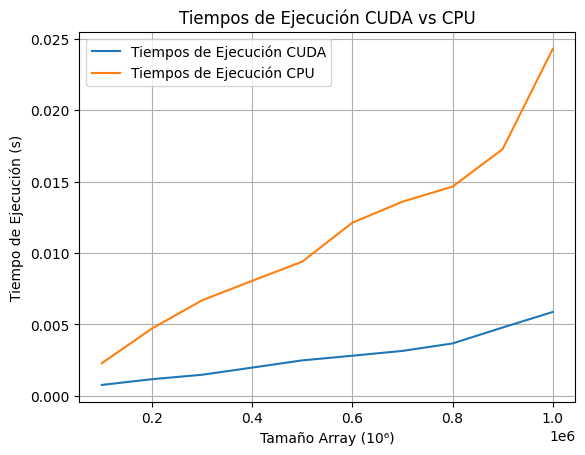

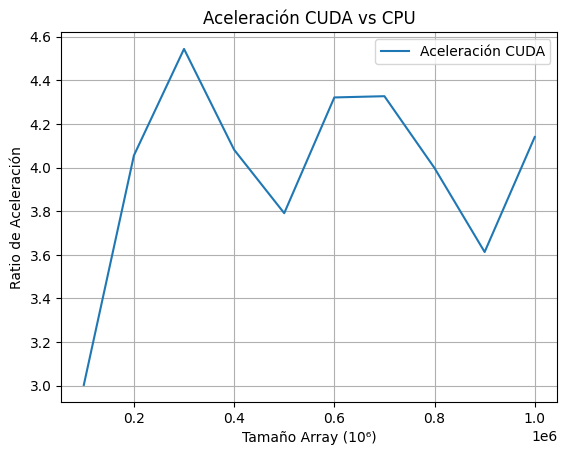

In [11]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

df_cuda = pd.read_csv("time.txt", sep=' ', header=None, names=['Size', 'Time'])
df_cpu = pd.read_csv("time_cpu.txt", sep=' ', header=None, names=['Size', 'Time'])

sizes = df_cuda['Size']
time_cuda = df_cuda['Time']
time_cpu = df_cpu['Time']

sizes = np.unique(sizes)

mean_times_cuda = []
mean_times_cpu = []
for i in range(10):
  mean_times_cuda.append(np.mean(time_cuda[i::10]))
  mean_times_cpu.append(np.mean(time_cpu[i::10]))

plt.plot(sizes, mean_times_cuda, label='Tiempos de Ejecución CUDA')
plt.plot(sizes, mean_times_cpu, label='Tiempos de Ejecución CPU')
plt.title("Tiempos de Ejecución CUDA vs CPU")
plt.ylabel("Tiempo de Ejecución (s)")
plt.xlabel("Tamaño Array (10⁶)")
plt.legend()
plt.grid()
plt.show()

accel = np.array(mean_times_cpu) / np.array(mean_times_cuda)

plt.plot(sizes, accel, label='Aceleración CUDA')
plt.title("Aceleración CUDA vs CPU")
plt.ylabel("Ratio de Aceleración")
plt.xlabel("Tamaño Array (10⁶)")
plt.legend()
plt.grid()
plt.show()


Los tiempos de ejecución son menores para la ejecución con GPU resultando en una aceleración considerable que se encuentra entre un rango de 3,0 y 4,5 dentro de los tamaños de ejecución dados, por lo tanto se está consiguiendo emplear la paralelización masiva que ofrece la GPU a través de CUDA para el algoritmo stencil1D.

3. ¿Qué TAMAÑO DE BLOQUE (número de hilos por bloque) has utilizado?
¿Crees que es lo óptimo? Explique los resultados.

In [1]:
%%writefile stencil_1d.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdio.h>
#include <stdlib.h>
#include <sys/time.h>

#define RADIUS 3
#ifndef BLOCK_SIZE
#define BLOCK_SIZE 256
#endif

__global__ void stencil_1d(int *in, int *out, int n) {
  __shared__ int temp[BLOCK_SIZE + 2 * RADIUS];
  int gindex = threadIdx.x + blockIdx.x * blockDim.x;
  int lindex = threadIdx.x + RADIUS;

  temp[lindex] = in[gindex];
  if (threadIdx.x < RADIUS) {
    if (gindex >= RADIUS) {
        temp[lindex - RADIUS] = in[gindex - RADIUS];
    }
    if (gindex + BLOCK_SIZE < n) {
        temp[lindex + BLOCK_SIZE] = in[gindex + BLOCK_SIZE];
    }
  }

  __syncthreads();

  int result = 0;
  for (int offset = -RADIUS; offset <= RADIUS; offset++)
    result += temp[lindex + offset];

  out[gindex] = result;
}

int main(int argc, char **argv) {
  int *in, *out;
  int *d_in, *d_out;

  if (argc < 2) {
    return -1;
  }

  int n = atoi(argv[1]);
  if (n == 0) {
    return -1;
  }

  int size = n * sizeof(int);
  struct timeval start_time, end_time;

  in = (int *)malloc(size);
  out = (int *)malloc(size);

  for (int i = 0; i < n; i ++) {
    in[i] = i;
  }

  cudaMalloc((void **)&d_in, size);
  cudaMalloc((void **)&d_out, size);

  gettimeofday(&start_time, NULL);
  cudaMemcpy(d_in, in, size, cudaMemcpyHostToDevice);
  stencil_1d<<<(n + BLOCK_SIZE - 1) / BLOCK_SIZE, BLOCK_SIZE>>>(d_in, d_out, n);
  cudaMemcpy(out, d_out, size, cudaMemcpyDeviceToHost);
  gettimeofday(&end_time, NULL);

  FILE *time = fopen("time_block_size.txt", "a");;

  double elapsed_time = (end_time.tv_sec - start_time.tv_sec) + ((end_time.tv_usec - start_time.tv_usec) / 1e6);

  fprintf(time, "%d %d %lf\n", n, BLOCK_SIZE, elapsed_time);

  fclose(time);

  free(in);
  free(out);
  cudaFree(d_in);
  cudaFree(d_out);

  return 0;
}


Overwriting stencil_1d.cu


In [9]:
!rm time_block_size.txt
for i in range(100000, 1100000, 100000):
  blocks = 32
  for _ in range(1, 7):
    !nvcc stencil_1d.cu -DBLOCK_SIZE={blocks} -o stencil_1d_cuda
    !nvprof ./stencil_1d_cuda {i}
    blocks = blocks * 2

==25360== NVPROF is profiling process 25360, command: ./stencil_1d_cuda 100000
==25360== Profiling application: ./stencil_1d_cuda 100000
==25360== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   45.06%  43.039us         1  43.039us  43.039us  43.039us  [CUDA memcpy DtoH]
                   40.13%  38.335us         1  38.335us  38.335us  38.335us  [CUDA memcpy HtoD]
                   14.81%  14.144us         1  14.144us  14.144us  14.144us  stencil_1d(int*, int*, int)
      API calls:   99.49%  194.84ms         2  97.420ms  5.0250us  194.84ms  cudaMalloc
                    0.24%  465.58us         2  232.79us  109.46us  356.12us  cudaMemcpy
                    0.12%  233.31us         1  233.31us  233.31us  233.31us  cudaLaunchKernel
                    0.07%  146.37us       114  1.2830us     155ns  58.664us  cuDeviceGetAttribute
                    0.06%  124.31us         2  62.155us  16.549us  107.76us  cudaFree
  

In [6]:
!cat time_block_size.txt

100000 32 0.000772
100000 64 0.000800
100000 128 0.001097
100000 256 0.000889
100000 512 0.000627
100000 1024 0.000776
200000 32 0.001346
200000 64 0.001363
200000 128 0.001276
200000 256 0.001860
200000 512 0.001342
200000 1024 0.001473
300000 32 0.001665
300000 64 0.001773
300000 128 0.001419
300000 256 0.002044
300000 512 0.001826
300000 1024 0.001507
400000 32 0.002038
400000 64 0.001922
400000 128 0.001988
400000 256 0.005328
400000 512 0.001877
400000 1024 0.002033
500000 32 0.002383
500000 64 0.002369
500000 128 0.002286
500000 256 0.002814
500000 512 0.002415
500000 1024 0.002287
600000 32 0.002851
600000 64 0.003126
600000 128 0.004416
600000 256 0.003108
600000 512 0.002735
600000 1024 0.003120
700000 32 0.003142
700000 64 0.003135
700000 128 0.003089
700000 256 0.003360
700000 512 0.004050
700000 1024 0.003685
800000 32 0.003542
800000 64 0.003734
800000 128 0.004039
800000 256 0.007412
800000 512 0.003728
800000 1024 0.003579
900000 32 0.004033
900000 64 0.004592
900000 128

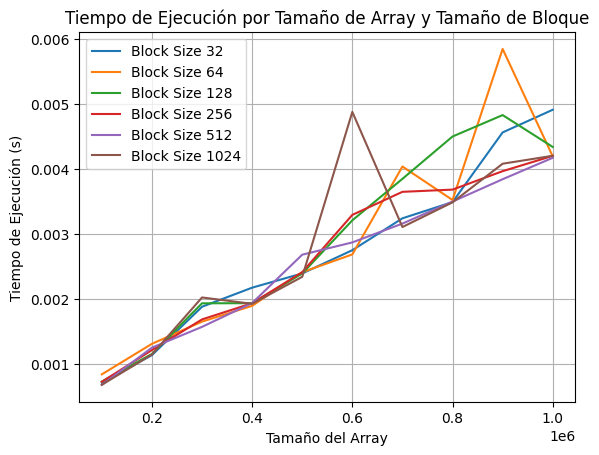

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("time_block_size.txt", sep=' ', header=None,
                 names=['Size', 'Block_Size', 'Time'])

block_sizes = np.unique(df['Block_Size'])

for block_size in block_sizes:
    plot = df[df['Block_Size'] == block_size]
    plt.plot(plot['Size'], plot['Time'], label=f'Block Size {block_size}')

plt.xlabel('Tamaño del Array')
plt.ylabel('Tiempo de Ejecución (s)')
plt.title('Tiempo de Ejecución por Tamaño de Array y Tamaño de Bloque')
plt.legend()
plt.grid()
plt.show()


Para los tamaños de array elegidos no se observan diferencias significativas en los tiempos de ejecución en función del tamaño de bloque. Se han elegido multiplos de 32 para el número de hilos por bloque, dado que los warps en CUDA están conformados por conjuntos de 32 hilos, de esta forma evitamos que algunos hilos queden inactivos y se pierda eficiencia. Por este motivo se ha elegido como tamaño de bloque 256, puesto que es un múltiplo de 32 y podemos disponer de 8 warps ejecutándose cada uno en un multiprocesador, aunque es importante destacar que expirementalmente no se observa un cambio de tiempos de ejecución entre cualquier múltiplo de 32.